# QR Decomposition Experiment

This notebook demonstrates:
- How to run QR decomposition experiments (Householder, WY, Block methods)
- How to collect residual and orthogonality errors
- How to save and reload results
- How to visualize results using bar charts and line plots

Modules used:
- `QRExperiment` from `core/qr_factorization.py`
- Plotting functions from `core/plotter.py`


In [6]:
import numpy as np
import json
from core.plotter import plot_qr_metrics_bar, plot_qr_metrics_line
from qr_factorization import QRExperiment

# Define matrix sizes and floating point types
sizes = [(100, 50), (200, 100), (400, 200)]
dtypes = [np.float32, np.float64]
block_size = 32

# Initialize experiment runner
exp = QRExperiment(dtypes=dtypes, sizes=sizes, block_size=block_size)


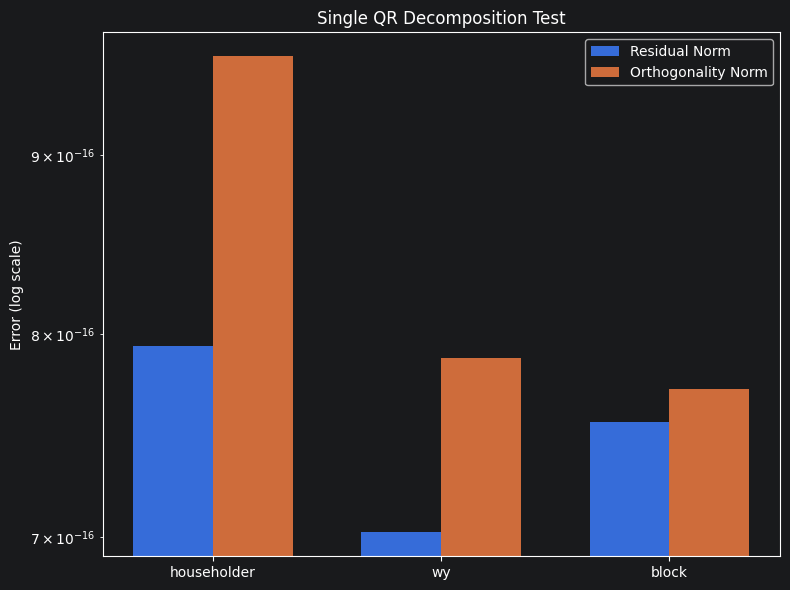

In [7]:
# Run QR decomposition on one matrix
single_res = exp.run_single(m=200, n=100, dtype=np.float64)

# Visualize using bar chart
plot_qr_metrics_bar(single_res, title="Single QR Decomposition Test")


In [8]:
import pprint
from error_analysis import run_qr_experiments, fit_error_growth, make_fit_table

n_values = np.round(
    np.logspace(np.log10(20), np.log10(512), num=12)
).astype(int)

df = run_qr_experiments(
    n_values=n_values,
    precisions=(np.float32, np.float64),
    repeats=10,
    block_size=32,
    seed=42,
    data_type="uniform",
)

df.to_csv("qr_error_results.csv", index=False)

df.head()

fit_df = fit_error_growth(df)
fit_table = make_fit_table(fit_df)

pprint.pp(fit_table)

             method precision             c                               \
metric                        Least Squares Orthogonality Reconstruction   
0          Block QR   float32        -2.035       -15.894        -17.193   
1          Block QR   float64        -1.889       -36.593        -35.956   
2       Householder   float32        -2.035       -15.889        -17.133   
3       Householder   float64        -1.889       -36.391        -37.025   
4                WY   float32        -2.035       -15.926        -17.167   
5                WY   float64        -1.889       -36.029        -37.032   

                   k                                  r_squared                \
metric Least Squares Orthogonality Reconstruction Least Squares Orthogonality   
0              0.004         0.000          0.234         0.008         0.000   
1             -0.025         0.429          0.196         0.099         0.967   
2              0.004         0.003          0.338         0.008    

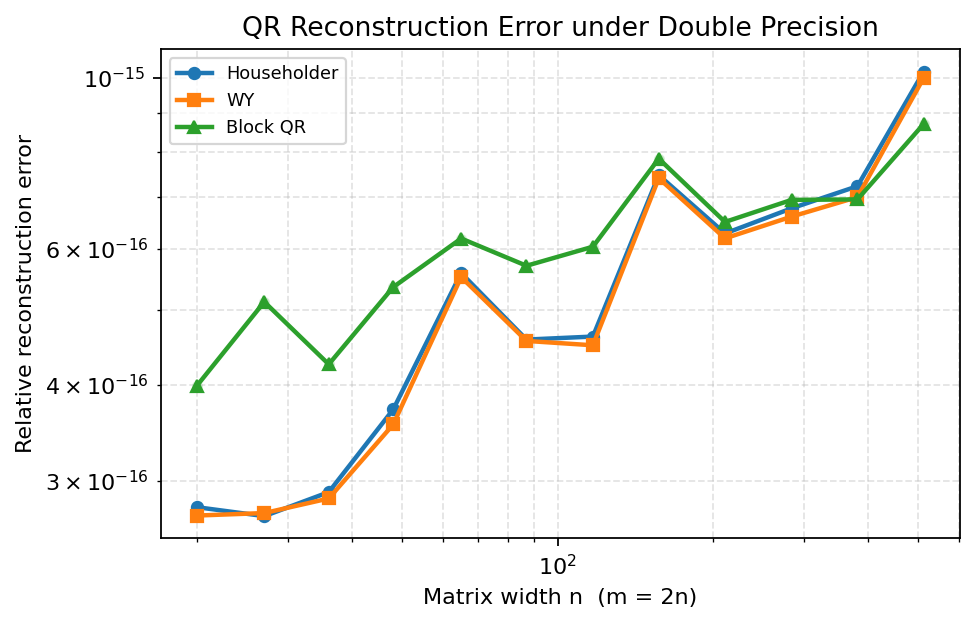

In [9]:
from core.plotter import plot_qr_metric_for_ppt

plot_qr_metric_for_ppt(
    df,
    metric="reconstruction",
    title="QR Reconstruction Error under Double Precision",
    ylabel="Relative reconstruction error",
    save_path="qr_reconstruction_float64_ppt.png",
    show_samples=True,
    show_fit=False,
)

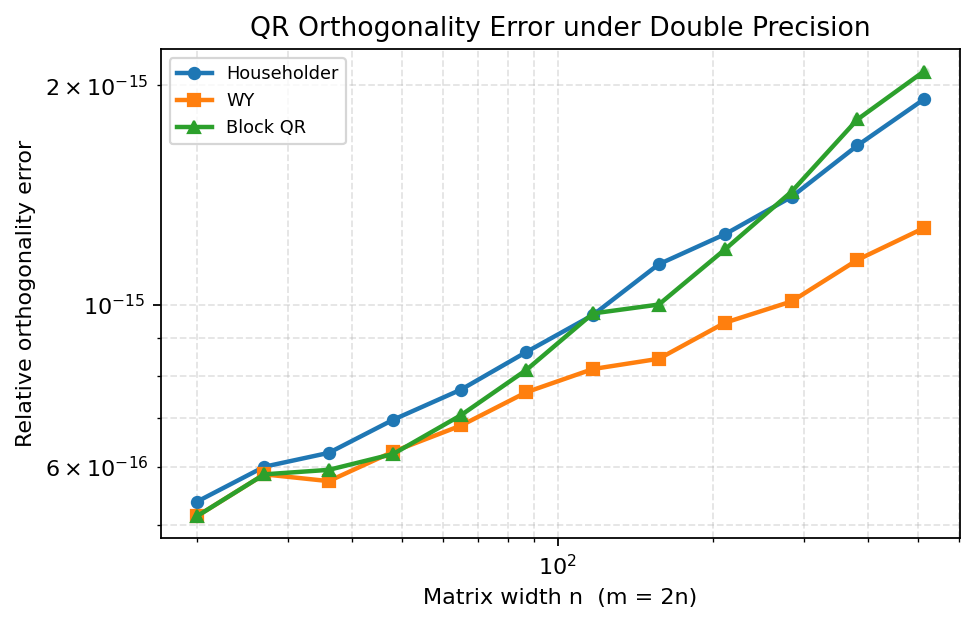

In [10]:
plot_qr_metric_for_ppt(
    df,
    metric="orthogonality",
    title="QR Orthogonality Error under Double Precision",
    ylabel="Relative orthogonality error",
    save_path="qr_orthogonality_float64_ppt.png",
    show_samples=True,
    show_fit=False,
)

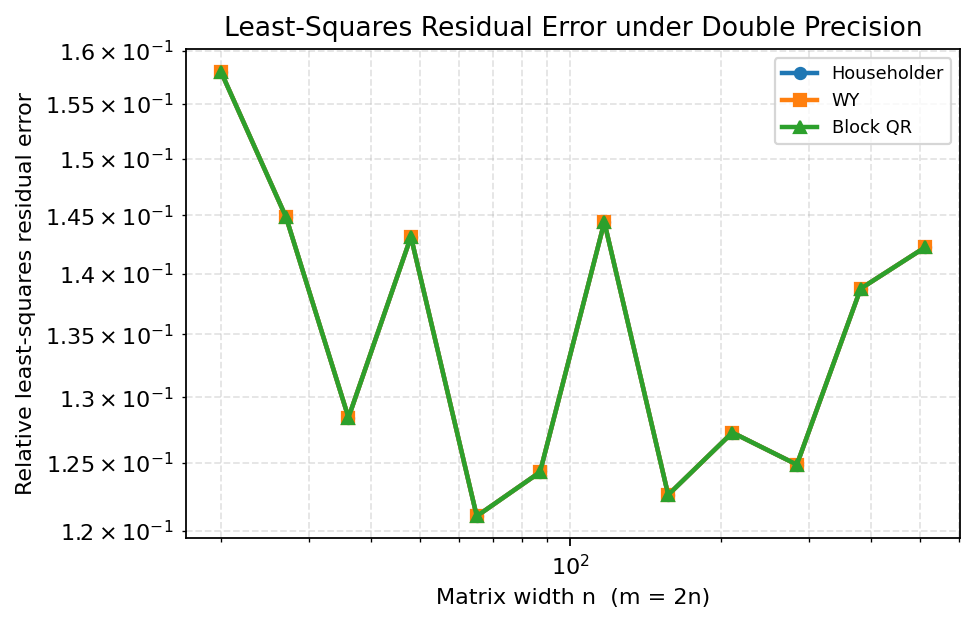

In [11]:
plot_qr_metric_for_ppt(
    df,
    metric="least_squares",
    title="Least-Squares Residual Error under Double Precision",
    ylabel="Relative least-squares residual error",
    save_path="qr_least_squares_float64_ppt.png",
    show_samples=True,
    show_fit=False,
)